# 다국어(한국어, 중국어, 영어) 정보추출 실습

개체명 인식(NER), 관계 추출(Relation Extraction) 을 수행하고 시각화를 통해 정보추출의 전체 과정을 이해한다.

In [ ]:
# 설치 (Colab / Jupyter Notebook)
!pip install spacy transformers torch networkx matplotlib
!python -m spacy download en_core_web_sm
!python -m spacy download zh_core_web_sm
!pip install spacy spacy-stanza kss transformers torch networkx matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 35.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 23.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('zh_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.0/163.0 kB 2.5 MB/s eta 0:00:00
     ━━━

# ① spacy를 활용한 개체명 인식 (Named Entity Recognition, NER)

In [ ]:
# =============================
# 🧠 영어 개체명 인식 (NER) 실습 예제
# =============================

import spacy
from spacy import displacy   # 시각화 도구

# 1️⃣ 영어 NER 모델 로드
#    - spaCy에서 기본으로 제공하는 영어 모델 사용
#    - 'en_core_web_sm' : 소형(small) 영어 모델
nlp = spacy.load("en_core_web_sm")

# 2️⃣ 분석할 문장 입력
#    - 문장 안에는 인물(Person), 조직(Organization), 날짜(Date), 장소(Location) 등이 포함됨
text = "Steve Jobs founded Apple in 1976 in California."

# 3️⃣ 모델에 문장 전달 → 분석 수행
doc = nlp(text)

# 4️⃣ 개체명 인식 결과 출력
#    - ent.text : 문장에서 인식된 단어(또는 구)
#    - ent.label_ : 개체 유형(Person, Org, Date 등)
for ent in doc.ents:
    print(f"{ent.text:<15} | {ent.label_}")

# 5️⃣ 개체명 시각화
#    - displaCy.render()를 이용하면 주피터 노트북에서
#      문장 내 엔티티를 색상으로 표시해줌
displacy.render(doc, style="ent", jupyter=True)

Steve Jobs      | PERSON
Apple           | ORG
1976            | DATE
California      | GPE


In [ ]:
# =============================
# 🧠 중국어 개체명 인식 (NER) 실습 예제
# =============================

import spacy
from spacy import displacy   # 시각화 도구

# 1️⃣ 중국어 NER 모델 로드
#    - spaCy에서 기본 제공하는 중국어 모델 (zh_core_web_sm)
#    - 품사 분석, 개체명 인식(NER), 의존 구문 분석 기능 포함
nlp_zh = spacy.load("zh_core_web_sm")

# 2️⃣ 분석할 중국어 문장 입력
#    - 문장 안에는 인물(马云), 시간(1999年), 장소(杭州), 조직(阿里巴巴集团)이 포함됨
text_zh = "马云于1999年在杭州创立了阿里巴巴集团。"

# 3️⃣ 모델에 문장 전달 → 자연어 분석 수행
doc_zh = nlp_zh(text_zh)

# 4️⃣ 개체명 인식 결과 출력
#    - ent.text : 문장에서 추출된 개체명 문자열
#    - ent.label_ : 개체 유형 (PER, ORG, LOC, DATE 등)
for ent in doc_zh.ents:
    print(f"{ent.text:<15} | {ent.label_}")

# 5️⃣ 개체명 시각화
#    - displaCy.render()를 이용하면 주피터 노트북에서
#      인식된 개체를 색상별로 하이라이트하여 표시
displacy.render(doc_zh, style="ent", jupyter=True)

马云于             | GPE
1999年           | DATE
杭州              | GPE
阿里巴巴集团          | ORG


# ② 관계 그래프 시각화 예제 (Relation Graph Demo)

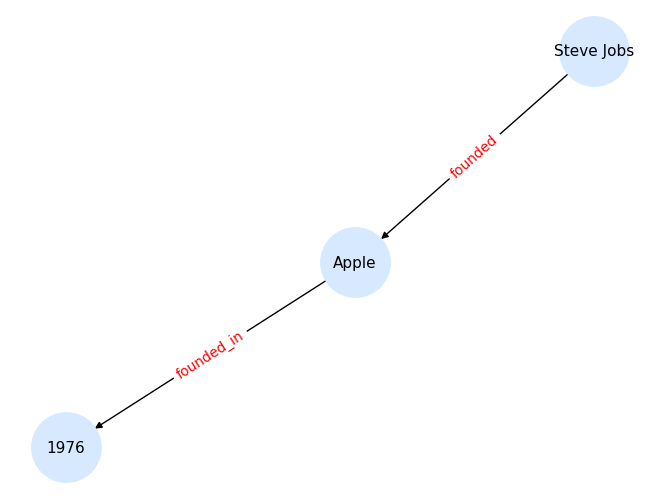

In [ ]:
# =============================
# 📊 관계 그래프 시각화 예제 (Relation Graph Demo)
# =============================

import networkx as nx
import matplotlib.pyplot as plt

# 1️⃣ 관계 데이터 정의
#   - (주어, 관계, 목적어)의 형태로 "삼중(triple)" 구조를 만듭니다.
#   - 여기서는 예시로 "Steve Jobs가 Apple을 설립했다"를 표현합니다.
triples = [
    ("Steve Jobs", "founded", "Apple"),
    ("Apple", "founded_in", "1976")
]

# 2️⃣ 방향 그래프(Directed Graph) 생성
#   - networkx의 DiGraph()는 화살표 방향이 있는 그래프를 만듭니다.
G = nx.DiGraph()

# 3️⃣ 각 관계(triple)를 그래프의 엣지(edge)로 추가
#   - add_edge(출발노드, 도착노드, label=관계명)
for h, r, t in triples:
    G.add_edge(h, t, label=r)

# 4️⃣ 노드의 위치를 자동으로 배치 (spring_layout)
#   - seed 값이 고정되어야 매번 비슷한 모양으로 표시됩니다.
pos = nx.spring_layout(G, seed=42)

# 5️⃣ 노드(개체) 시각화
#   - node_color: 노드 색상
#   - node_size: 노드 크기
#   - font_size: 노드 글자 크기
nx.draw(
    G, pos,
    with_labels=True,
    node_size=2500,
    node_color="#D7E9FF",
    font_size=11
)

# 6️⃣ 관계(엣지) 라벨 표시
#   - 각 화살표 위에 관계 이름(founded, founded_in)을 적습니다.
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_color='red'
)

# 7️⃣ 그래프 출력
#   - plt.show()를 실행하면 노드와 관계가 시각적으로 표시됩니다.
plt.show()

# 규칙 기반 관계 추출
- 영어: “founded/ acquired …” 패턴 데모

In [ ]:
# =============================
# 🔗 영어 관계 추출 (Relation Extraction) 기본 예제
# =============================

# 1️⃣ spaCy 설치 및 영어 모델 다운로드
!pip install spacy > /dev/null
!python -m spacy download en_core_web_sm > /dev/null

# 2️⃣ 라이브러리 불러오기
import spacy
from spacy.matcher import DependencyMatcher  # 의존 구문 기반 패턴 매칭 도구

# 3️⃣ 영어 모델 로드
#    - 'en_core_web_sm': 영어 소형 모델 (품사, 의존, 개체명 포함)
nlp_en = spacy.load("en_core_web_sm")

# ============================================
# 🧩 함수 정의: 문장에서 (주어, 동사, 목적어) 관계 추출
# ============================================
def extract_relations_en(text):
    # 문장 분석 수행
    doc = nlp_en(text)

    # DependencyMatcher 객체 생성 (의존구문 트리 탐색용)
    matcher = DependencyMatcher(nlp_en.vocab)

    # 4️⃣ 관계 패턴 정의 (SVO: Subject–Verb–Object)
    #    - nsubj : 주어(verb ← subject)
    #    - dobj : 목적어(verb → object)
    #    - attr/pobj : 보어·전치사 목적어 등도 포함
    pattern_svo = [
        {"RIGHT_ID": "verb", "RIGHT_ATTRS": {"POS": "VERB"}},  # 동사 노드
        {"LEFT_ID": "verb", "REL_OP": ">", "RIGHT_ID": "subj", "RIGHT_ATTRS": {"DEP": "nsubj"}},  # 주어 연결
        {"LEFT_ID": "verb", "REL_OP": ">", "RIGHT_ID": "obj", "RIGHT_ATTRS": {"DEP": {"IN": ["dobj", "attr", "pobj"]}}}  # 목적어 연결
    ]

    # 5️⃣ 패턴 등록
    matcher.add("SVO", [pattern_svo])

    # 6️⃣ 패턴 일치 결과 탐색
    triples = []
    for match_id, token_map in matcher(doc):
        # token_map에는 "verb, subj, obj"의 인덱스가 담김
        verb = doc[token_map[0]]
        subj = doc[token_map[1]]
        obj  = doc[token_map[2]]

        # (주어, 동사, 목적어) 형태의 관계 추출
        triples.append((subj.text, verb.lemma_, obj.text))

    # 추출된 삼중(triple) 리스트 반환
    return triples

# ============================================
# 📘 테스트 문장
# ============================================
text = "Steve Jobs founded Apple in 1976. Microsoft acquired GitHub in 2018."

# 7️⃣ 결과 출력
print("=== 추출된 관계 (Subject, Verb, Object) ===")
print(extract_relations_en(text))

=== 추출된 관계 (Subject, Verb, Object) ===
[('Jobs', 'found', 'Apple'), ('Microsoft', 'acquire', 'GitHub')]


=== 추출된 관계 ===
('Jobs', 'found', 'Apple')
('Microsoft', 'acquire', 'GitHub')


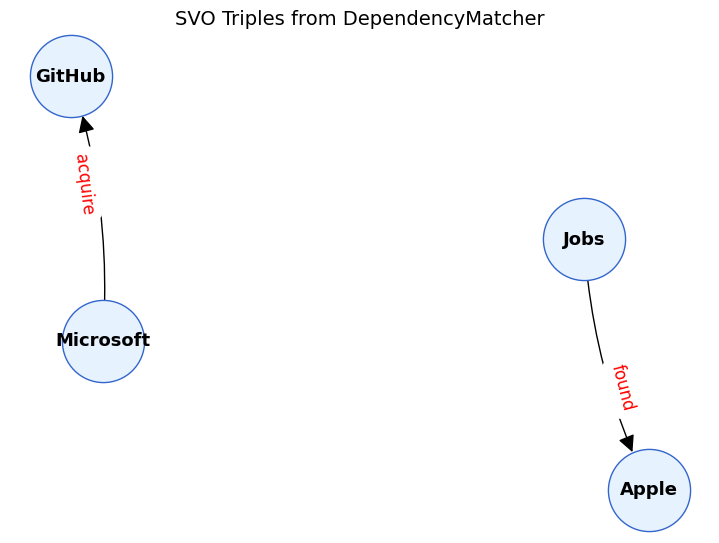

In [ ]:
# ============================================
# 🎨 추출 결과(triples)를 관계 그래프로 시각화
# ============================================
!pip install -q networkx matplotlib

import networkx as nx
import matplotlib.pyplot as plt

def visualize_triples(triples, title="Relation Graph (SVO)"):
    """
    triples: [(subject, verb, object), ...]
    - 노드 간격과 화살표를 보기 좋게 조정한 버전
    """
    if not triples:
        print("표시할 트리플이 없습니다.")
        return

    # 방향 그래프 생성
    G = nx.DiGraph()
    for s, v, o in triples:
        G.add_edge(s, o, label=v)

    # 🔹 노드 간격 조정: k 값↑ → 간격 넓어짐
    pos = nx.spring_layout(G, k=1.2, scale=2.0, seed=42)

    plt.figure(figsize=(7, 5))
    nx.draw(
        G, pos,
        with_labels=True,
        node_size=3500,
        node_color="#E7F2FF",
        edgecolors="#3366CC",
        font_size=13,
        font_weight="bold",
        arrows=True,
        arrowsize=25,        # 화살표 크기
        connectionstyle="arc3,rad=0.1"  # 엣지 곡선 (겹침 방지)
    )

    # 🔹 관계 라벨 표시 (엣지 가운데, 약간 위로)
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edge_labels,
        font_color="red",
        font_size=12,
        label_pos=0.6          # 화살표 방향 쪽으로 약간 이동
    )

    plt.title(title, fontsize=14)
    plt.axis("off")
    plt.show()

# ============================================
# 🔎 실제 시각화 실행
# ============================================
triples = extract_relations_en(text)
print("=== 추출된 관계 ===")
for t in triples:
    print(t)

visualize_triples(triples, title="SVO Triples from DependencyMatcher")

# ③ Transformers 기반 영어 NER (Hugging Face)

In [ ]:
# =============================
# 🤖 사전학습(Pretrained) 언어모델을 이용한 영어 개체명 인식 (NER)
# =============================

from transformers import pipeline  # 🤗 Transformers의 고수준 API (Pipeline) 불러오기

# 1️⃣ NER 파이프라인 생성
#   - "ner": 개체명 인식(Named Entity Recognition) 작업
#   - model="dslim/bert-base-NER": 영어 NER용 사전학습된 BERT 모델
#   - aggregation_strategy="simple": 같은 개체 토큰을 하나로 합침 (예: "Steve" + "Jobs" → "Steve Jobs")
ner = pipeline("ner", model="dslim/bert-base-NER", aggregation_strategy="simple")

# 2️⃣ 분석할 문장 입력
#   - 예시 문장에는 인물(Person), 조직(Organization), 날짜(Date), 장소(Location)이 포함되어 있음
#   - 다른 문장 예시: “Elon Musk acquired Twitter in 2022 for 44 billion dollars.”
text = "Steve Jobs founded Apple in 1976 in California."

# 3️⃣ 모델에 문장 입력 → 개체명 인식 수행
result = ner(text)

# 4️⃣ 결과 출력
#   - r['word'] : 인식된 개체명 문자열
#   - r['entity_group'] : 개체 유형 (PER, ORG, LOC, DATE 등)
#   - r['score'] : 신뢰도(Confidence Score)
print("=== 개체명 인식 결과 ===")
for r in result:
    print(f"{r['word']:<15} | {r['entity_group']:<10} | {r['score']:.3f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


=== 개체명 인식 결과 ===
Steve Jobs      | PER        | 0.999
Apple           | ORG        | 0.999
California      | LOC        | 1.000


# Transformers 기반 한국어 NER (Hugging Face)

In [ ]:
# =============================
# 🌐 사전학습(Pretrained) 언어모델을 이용한 한국어 개체명 인식 (NER)
# =============================

from transformers import pipeline  # 🤗 Transformers의 고수준 API (Pipeline) 불러오기

# 1️⃣ NER 파이프라인 생성
#   - "ner": Named Entity Recognition (개체명 인식)
#   - model="Davlan/xlm-roberta-base-ner-hrl"
#       : XLM-RoBERTa 기반 다국어 NER 모델
#         (영어, 중국어, 한국어 등 고자원 언어에서 잘 동작)
#   - aggregation_strategy="simple"
#       : 같은 개체 토큰을 하나로 합침 (예: “이” + “재용” → “이재용”)
ner_multi = pipeline("ner", model="Davlan/xlm-roberta-base-ner-hrl", aggregation_strategy="simple")

# 2️⃣ 분석할 문장 입력
#   - 한국어 문장 예시
#   - 인물(PER), 날짜(DATE), 장소(LOC), 조직(ORG) 등이 포함되어 있음
sent_ko = "이재용은 2025년에 서울에서 삼성전자 신제품을 발표했다."

# 3️⃣ 모델에 문장 입력 → 개체명 인식 수행
result = ner_multi(sent_ko)

# 4️⃣ 결과 출력
#   - r['word'] : 인식된 단어 또는 구
#   - r['entity_group'] : 개체 유형 (PER, ORG, LOC, DATE 등)
#   - r['score'] : 인식 신뢰도(Confidence Score)
print("=== 한국어 개체명 인식 결과 ===")
for r in result:
    print(f"{r['word']:<12} | {r['entity_group']:<8} | {r['score']:.3f}")

config.json:   0%|          | 0.00/980 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cpu


=== 한국어 개체명 인식 결과 ===
이재용          | PER      | 0.982
서울           | LOC      | 0.994
삼성전자         | ORG      | 1.000


# Transformers 기반 중국어 NER (Hugging Face)
### bert-base-chinese 기반으로 학습된 중국어 개체명 인식 모델
- ckiplab/bert-base-chinese-ner (대만 Academia Sinica 제작) 사용
- 이 모델은 PERSON(人名), ORGANIZATION(组织), LOCATION(地名) 등을 잘 인식함

In [ ]:
# ==========================================
# 🇨🇳 중국어 NER + displaCy 시각화 (Transformers → spaCy 주입)
# ==========================================

# 1) 설치
!pip install -q transformers spacy
!python -m spacy download zh_core_web_sm -q

# 2) 라이브러리
from transformers import pipeline
import spacy
from spacy import displacy

# 3) 중국어 NER 파이프라인 (중국어 전용 모델 권장)
#    - 대안: 다국어 모델 ner_multi = pipeline("ner", model="Davlan/xlm-roberta-base-ner-hrl", aggregation_strategy="simple")
ner_zh = pipeline("ner", model="ckiplab/bert-base-chinese-ner", aggregation_strategy="simple")

# 4) 분석할 문장: "마윈(马云)은 1999년에 항저우에서 알리바바 그룹을 설립했습니다."
text_zh = "马云于1999年在杭州创立了阿里巴巴集团。"

# 5) NER 실행 (문자 오프셋 포함)
ners = ner_zh(text_zh)
print("=== NER 결과 ===")
for r in ners:
    print(f"{r['word']:<12} | {r['entity_group']:<6} | {r['score']:.3f} | span=({r['start']},{r['end']})")

# 6) spaCy 중국어 모델로 문서 생성
nlp_zh = spacy.load("zh_core_web_sm")
doc = nlp_zh(text_zh)

# 7) Transformers 결과 → spaCy 엔티티 스팬으로 주입
#    - alignment_mode="contract": 토큰 경계와 정확히 일치하지 않아도 최대한 맞춰서 스팬 생성
label_map = {"PER": "PERSON", "ORG": "ORG", "LOC": "GPE", "DATE": "DATE"}
spans = []
for r in ners:
    start, end = r["start"], r["end"]
    label = label_map.get(r["entity_group"], r["entity_group"])
    span = doc.char_span(start, end, label=label, alignment_mode="contract")
    if span is not None:
        spans.append(span)

# 기존 엔티티를 대체
doc.set_ents(spans, default="unmodified")

# 8) displaCy 시각화 (주피터/코랩에서 컬러 하이라이트)
displacy.render(doc, style="ent", jupyter=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 47.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('zh_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Device set to use cuda:0


=== NER 결과 ===
马            | PERSON | 1.000 | span=(0,1)
云            | PERSON | 0.998 | span=(1,2)
1999         | DATE   | 1.000 | span=(3,7)
年            | DATE   | 1.000 | span=(7,8)
杭            | GPE    | 1.000 | span=(9,10)
州            | GPE    | 1.000 | span=(10,11)
阿 里 巴 巴 集    | ORG    | 1.000 | span=(14,19)
团            | ORG    | 1.000 | span=(19,20)


# 추출된 IE 결과(엔티티·관계·사건 트리플)”를 활용하는 예제

### 공통: 예시 트리플 준비

In [ ]:
# (subject, relation, object) 형태의 예시 트리플
triples = [
    # 영어
    ("Steve Jobs", "founded", "Apple"),
    ("Apple", "founded_in", "1976"),
    ("Microsoft", "acquired", "GitHub"),
    ("GitHub", "acquired_in", "2018"),
    # 한국어
    ("이재용", "announce", "신제품"),
    ("이재용", "announce_in", "서울"),
    ("이벤트", "date", "2025년"),
    # 중국어
    ("马云", "创立", "阿里巴巴集团"),
    ("阿里巴巴集团", "创立时间", "1999年"),
]

### 1) 간단 질의응답(FAQ형) — 트리플로 바로 답 찾기

In [ ]:
# =============================
# 💬 문자열 매칭 기반의 간단한 질의응답(QA) 예제
#  - 입력: question (질문), triples (IE 결과 리스트)
#  - 출력: 짧은 자연어 답변
# =============================

def answer(question: str, triples):
    # 사용자의 질문을 소문자로 변환 (대소문자 구분 방지)
    q = question.lower()

    # ---------------------------------------------------------
    # 1️⃣ 질문 유형: Who founded X?
    #   예: "Who founded Apple?"
    #   → Apple was founded by Steve Jobs.
    # ---------------------------------------------------------
    if "who founded" in q:
        # "who founded"를 제거하고 남은 부분이 대상(회사명)
        target = q.replace("who founded", "").strip().rstrip("?")

        # triples에서 founded(또는 创立) 관계를 찾아서 일치하는 객체(o)를 검색
        for s, r, o in triples:
            if r in ("founded", "创立") and o.lower() == target:
                return f"{o} was founded by {s}."
        return "I don't know."

    # ---------------------------------------------------------
    # 2️⃣ 질문 유형: What did X acquire?
    #   예: "What did Microsoft acquire?"
    #   → Microsoft acquired GitHub.
    # ---------------------------------------------------------
    if "what did" in q and "acquire" in q:
        # "what did"과 "acquire" 사이의 단어가 주체(actor)
        actor = q.split("what did")[1].split("acquire")[0].strip()

        # triples에서 acquired 관계를 찾아서 일치하는 주체(s)를 검색
        for s, r, o in triples:
            if r == "acquired" and s.lower() == actor:
                return f"{actor} acquired {o}."
        return "I don't know."

    # ---------------------------------------------------------
    # 3️⃣ 질문 유형: When was X founded?
    #   예: "When was Apple founded?"
    #   → Apple was founded in 1976.
    # ---------------------------------------------------------
    if "when was" in q and "founded" in q:
        # "when was"와 "founded"를 제거하고 남은 부분이 대상(회사명)
        target = q.replace("when was", "").replace("founded", "").strip().rstrip("?")

        # triples에서 founded_in(또는 创立时间) 관계를 찾아서 해당 연도를 반환
        for s, r, o in triples:
            if r in ("founded_in", "创立时间") and s.lower() == target:
                return f"{target} was founded in {o}."
        return "I don't know."

    # ---------------------------------------------------------
    # 4️⃣ 위 조건에 해당하지 않는 질문은 기본 메시지 반환
    # ---------------------------------------------------------
    return "Sorry, this demo only supports a few question types."

# 5️⃣ 실행 예시
print(answer("Who founded Apple?", triples))         # Apple was founded by Steve Jobs.
print(answer("What did Microsoft acquire?", triples)) # Microsoft acquired GitHub.
print(answer("When was Apple founded?", triples))     # Apple was founded in 1976.

Apple was founded by Steve Jobs.
microsoft acquired GitHub.
I don't know.


### 2) Knowledge Graph(간이) 구성 & 경로 질의

In [ ]:
# =============================
# 🌐 정보추출(IE) 결과를 활용한 지식그래프 탐색 예제
# =============================

import networkx as nx

# -------------------------------------------------
# 1️⃣ 방향 그래프 생성
#    - triples: (subject, relation, object)의 리스트
#    - 각 트리플을 그래프의 엣지(edge)로 추가
# -------------------------------------------------
KG = nx.DiGraph()  # 방향 그래프 (화살표 방향 포함)

for s, r, o in triples:
    KG.add_edge(s, o, relation=r)  # s ──r──▶ o 형태의 엣지 생성

# -------------------------------------------------
# 2️⃣ 특정 노드(entity)의 이웃 노드(연결 관계) 조회 함수
# -------------------------------------------------
def neighbors(entity):
    # entity에서 나가는 엣지(→) : outgoing
    outs = [(t, KG[s][t]['relation']) for s, t in KG.out_edges(entity)]
    # entity로 들어오는 엣지(←) : incoming
    ins  = [(s, KG[s][t]['relation']) for s, t in KG.in_edges(entity)]

    # 결과를 딕셔너리 형태로 반환
    return {"outgoing": outs, "incoming": ins}

# 예시: Apple과 직접 연결된 관계 보기
print("=== Apple과 연결된 관계 ===")
print(neighbors("Apple"))

# -------------------------------------------------
# 3️⃣ 두 노드(a, b) 사이의 최단 경로(Shortest Path) 탐색
# -------------------------------------------------
def shortest_path_info(a, b):
    # a 또는 b가 그래프에 없으면 None 반환
    if a not in KG or b not in KG:
        return None

    try:
        # (1) 최단 경로 노드 리스트 구하기
        path = nx.shortest_path(KG, a, b)
        # 예: ['Steve Jobs', 'Apple', '1976']

        # (2) 각 엣지에 연결된 관계(verb) 추출
        rels = []
        for i in range(len(path) - 1):
            rels.append(KG[path[i]][path[i + 1]]['relation'])

        # (3) (출발노드, 관계, 도착노드) 형태로 묶어서 반환
        return list(zip(path[:-1], rels, path[1:]))

    except nx.NetworkXNoPath:
        # 경로가 없으면 None 반환
        return None

# 예시: Steve Jobs → Apple → 1976 경로 찾기
print("\n=== Steve Jobs → 1976 최단 경로 ===")
print(shortest_path_info("Steve Jobs", "1976"))

=== Apple과 연결된 관계 ===
{'outgoing': [('1976', 'founded_in')], 'incoming': [('Steve Jobs', 'founded')]}

=== Steve Jobs → 1976 최단 경로 ===
[('Steve Jobs', 'founded', 'Apple'), ('Apple', 'founded_in', '1976')]


### 3) 타임라인(연도) 추출 & 시각화

[('Apple', 'founded_in', 1976), ('GitHub', 'acquired_in', 2018)]


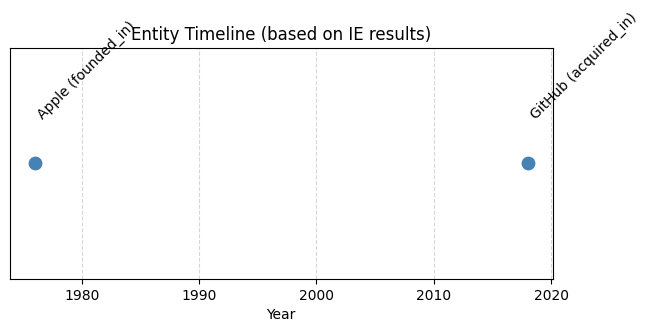

In [ ]:
# =============================
# 📅 Information Extraction 결과를 이용한 연도(Timeline) 시각화
# =============================

import re
import matplotlib.pyplot as plt

# ✅ 1) 연도(year)를 추출하는 간단한 함수
# 문자열에서 4자리 숫자(예: 1976, 2018 등)를 찾아서 정수형으로 반환합니다.
def extract_year(s):
    m = re.search(r"(19|20)\d{2}", s)   # 1900~2099 범위 연도 찾기
    return int(m.group()) if m else None

# ✅ 2) IE(정보추출) 결과에서 '연도 정보'가 있는 관계만 골라내기
# triples: (subject, relation, object) 형태의 리스트라고 가정
# 예: ("Apple", "founded_in", "1976")
events = []
for s, r, o in triples:
    if r in ("founded_in", "acquired_in"):  # 연도 관련 관계만 선택
        year = extract_year(o)
        if year:
            events.append((s, r, year))

# ✅ 3) 결과 확인
print(events)
# 예시 출력:
# [('Apple', 'founded_in', 1976), ('GitHub', 'acquired_in', 2018)]

# ✅ 4) 시각화용 데이터 준비
# labels: 각 점 위에 표시될 회사명 + 관계명
# years : X축에 표시될 연도
labels = [f"{a} ({r})" for a, r, y in events]
years  = [y for a, r, y in events]

# ✅ 5) 시각화 (Timeline 그래프)
plt.figure(figsize=(7, 3))

# X축은 연도, Y축은 모두 1 (한 줄에 나열)
plt.scatter(years, [1]*len(years), color="steelblue", s=80)

# 각 점 위에 텍스트(회사 이름 + 관계)를 회전해서 표시
for x, lab in zip(years, labels):
    plt.text(x, 1.02, lab, rotation=45, ha="left", va="bottom", fontsize=10)

# 축, 제목 등 꾸미기
plt.yticks([])                    # Y축 눈금 제거 (불필요)
plt.xlabel("Year")                # X축 이름
plt.title("Entity Timeline (based on IE results)")  # 그래프 제목
plt.grid(axis="x", linestyle="--", alpha=0.5)       # 연도 구분선(가이드)

plt.show()

In [ ]:
# (subject, relation, object) 형태의 예시 트리플
triples = [
    # 영어
    ("Steve Jobs", "founded", "Apple"),
    ("Apple", "founded_in", "1976"),
    ("Microsoft", "acquired", "GitHub"),
    ("GitHub", "acquired_in", "2018"),
    # 한국어
    ("이재용", "announce", "신제품"),
    ("이재용", "announce_in", "서울"),
    ("이벤트", "date", "2025년"),
    # 중국어
    ("马云", "创立", "阿里巴巴集团"),
    ("阿里巴巴集团", "创立时间", "1999年"),
]

### 4) 테이블(데이터프레임)로 정리 → 필터/검색

In [ ]:
# =============================
# 📊 정보추출 결과(triples)를 판다스 DataFrame으로 정리
# =============================

import pandas as pd

# 1️⃣ triples 리스트를 DataFrame으로 변환
#   - 각 열(column): subject, relation, object
df = pd.DataFrame(triples, columns=["subject", "relation", "object"])

# 전체 데이터 출력
print("=== 전체 트리플 목록 ===")
print(df)

# --------------------------------------------------
# 2️⃣ 특정 관계(relation)만 보기
#   - 예: relation이 'acquired'인 경우만 선택
# --------------------------------------------------
print("\n[acquired 관계만 필터링]")
print(df[df["relation"] == "acquired"])

# --------------------------------------------------
# 3️⃣ 한국어 트리플만 보기 (간단한 정규식 활용)
#   - [가-힣] : 한글 범위의 유니코드 패턴
#   - subject나 object 중 하나라도 한글이 포함되어 있으면 선택
# --------------------------------------------------
mask_ko = df["subject"].str.contains(r"[가-힣]") | df["object"].str.contains(r"[가-힣]")

print("\n[한국어 트리플만 필터링]")
print(df[mask_ko])

=== 전체 트리플 목록 ===
      subject     relation  object
0  Steve Jobs      founded   Apple
1       Apple   founded_in    1976
2   Microsoft     acquired  GitHub
3      GitHub  acquired_in    2018
4         이재용     announce     신제품
5         이재용  announce_in      서울
6         이벤트         date   2025년
7          马云           创立  阿里巴巴集团
8      阿里巴巴集团         创立时间   1999年

[acquired 관계만 필터링]
     subject  relation  object
2  Microsoft  acquired  GitHub

[한국어 트리플만 필터링]
  subject     relation object
4     이재용     announce    신제품
5     이재용  announce_in     서울
6     이벤트         date  2025년


### 5) 템플릿 기반 자동 문장 생성(보고서 요약)

| 관계 유형 (`relation`) | 출력 문장 형식                   | 예시 결과                        |
| ------------------ | -------------------------- | ---------------------------- |
| founded / 创立       | `{s} founded {o}.`         | Steve Jobs founded Apple.    |
| founded_in / 创立时间  | `{s} was founded in {o}.`  | Apple was founded in 1976.   |
| acquired           | `{s} acquired {o}.`        | Microsoft acquired GitHub.   |
| acquired_in        | `{s} was acquired in {o}.` | GitHub was acquired in 2018. |
| announce           | `{s} announced {o}.`       | 이재용 announced 신제품.           |
| announce_in        | `{s} announced in {o}.`    | 이재용 announced in 서울.         |


In [ ]:
# =============================
# 🗣️ IE(정보추출) 결과를 자연어 문장으로 바꾸는 함수
# =============================

def verbalize(triple):
    # triple은 (subject, relation, object) 형태의 튜플
    s, r, o = triple

    # 1️⃣ 회사 설립 관계
    #    예: ("Steve Jobs", "founded", "Apple")
    if r in ("founded", "创立"):
        return f"{s} founded {o}."          # Steve Jobs founded Apple.

    # 2️⃣ 설립 시기 관계
    #    예: ("Apple", "founded_in", "1976")
    if r in ("founded_in", "创立时间"):
        return f"{s} was founded in {o}."   # Apple was founded in 1976.

    # 3️⃣ 인수(acquire) 관계
    #    예: ("Microsoft", "acquired", "GitHub")
    if r == "acquired":
        return f"{s} acquired {o}."         # Microsoft acquired GitHub.

    # 4️⃣ 인수 시기 관계
    #    예: ("GitHub", "acquired_in", "2018")
    if r == "acquired_in":
        return f"{s} was acquired in {o}."  # GitHub was acquired in 2018.

    # 5️⃣ 발표(announce) 관계
    #    예: ("이재용", "announce", "신제품")
    if r == "announce":
        return f"{s} announced {o}."        # 이재용 announced 신제품.

    # 6️⃣ 발표 장소 관계
    #    예: ("이재용", "announce_in", "서울")
    if r == "announce_in":
        return f"{s} announced in {o}."     # 이재용 announced in 서울.

    # 7️⃣ 그 외 관계는 일반 표현으로 출력
    return f"{s} --{r}--> {o}"

# =============================
# 🧩 예시 triples 데이터
# =============================
triples = [
    ("Steve Jobs", "founded", "Apple"),
    ("Apple", "founded_in", "1976"),
    ("Microsoft", "acquired", "GitHub"),
    ("GitHub", "acquired_in", "2018"),
    ("이재용", "announce", "신제품"),
    ("이재용", "announce_in", "서울")
]

# =============================
# 🔎 모든 트리플을 자연어 문장으로 변환 후 출력
# =============================
for t in triples:
    print(verbalize(t))

Steve Jobs founded Apple.
Apple was founded in 1976.
Microsoft acquired GitHub.
GitHub was acquired in 2018.
이재용 announced 신제품.
이재용 announced in 서울.
